# Hail → Solar · M0 input data · source 01 — NOAA Storm Events (via Hydronos)

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M0 (raw evidence)

This is **one of several M0 source notebooks** under `m0_input_data/`. The whole point of the M0→M3
architecture is to test *multiple* input datasets behind one interface, then reconcile them:

- **`01_noaa_hydronos`** ← *this notebook* — NOAA Storm Events via the Hydronos API (**point reports**;
  `MAGNITUDE` = hail size in inches), plus FEMA NRI as a **reference-only** anchor.
- `02_mrms_aws` *(next)* — MRMS MESH from AWS Open Data (**gridded** → real event **footprints**).

Reconciling these sources into one clean event set is **not** a third M0 source — it's the **M0→M1** step
(the event catalog), so it lives in the M1/catalog layer (placed when we build Phase 2), not here.

Understanding the *raw hazard evidence* here is deliberately **method-neutral**: how we read the data is
the same regardless of the loss math downstream (the "right way vs old way" divergence lives in Phase 3
coupling / Phase 5 loss).

> Plan: `docs/plans/hail/` · Principles: `docs/principles/` (esp. *basics-spot-on* and
> *notebook_work / exploratory_data_notebooks*).

## Assumptions (this layer)

This notebook rests on **A1** region = 50-mi circle · **A2** severe threshold = 25.4 mm (1″). Plus
**NOAA-specific data caveats** (detailed in §1 and §7): **NRI is reference-only** — `hail_hlrb` is a loss
ratio vs community-building exposure, *never* our PV loss path (the canonical "interpret the base" trap);
**reports are population-biased** (→ NOAA is the *cross-check*, not the spine — DD-1); **magnitude is
reliable only from ~1996**. Full register:
[assumptions A1–A5](../../../docs/plans/hail/assumptions.md#m0--input-data).

In [1]:
from __future__ import annotations
import os, math
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from dotenv import load_dotenv

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

# Locate + load the gitignored .env (HYDRONOS_API_KEY) by walking up to the repo root.
def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (.env / AGENTS.md) not found")

ROOT = _repo_root()
load_dotenv(ROOT / ".env")
API_KEY = os.environ["HYDRONOS_API_KEY"]
print(f"repo root: {ROOT}")
print("HYDRONOS_API_KEY loaded:", bool(API_KEY))

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
HYDRONOS_API_KEY loaded: True


## A trimmed Hydronos hazard client

Adapted from the old repo's `BaseHydronosFetcher` — **kept**: the request mechanics. **Dropped**: the
GCS-cache + `disaster_analysis` monolith entanglement (the architecture we're escaping). A thin client
that returns clean DataFrames, nothing more.

In [2]:
class HydronosHazard:
    BASE = "https://api.hydronoslabs.com/hazard"

    def __init__(self, api_key: str):
        self.headers = {"accept": "application/json", "x-api-key": api_key}

    def _get(self, path: str, params: dict) -> dict:
        r = requests.get(f"{self.BASE}{path}", params=params, headers=self.headers, timeout=180)
        r.raise_for_status()
        return r.json()

    @staticmethod
    def _records(payload: dict) -> list:
        d = payload.get("data")
        if isinstance(d, dict):
            return [d]
        return d or []

    def nri_risk(self, lat: float, lon: float) -> pd.DataFrame:
        return pd.json_normalize(self._records(self._get("/risk", {"lat": lat, "lon": lon})))

    def noaa_storm(self, lat, lon, start, end, incident_type, distance=None) -> pd.DataFrame:
        params = {"lat": lat, "lon": lon, "startDate": start, "endDate": end, "incidentType": incident_type}
        if distance:
            params["distance"] = distance
        return pd.DataFrame(self._records(self._get("/hist/noaa_storm", params)))

haz = HydronosHazard(API_KEY)

## The asset — Hayhurst Texas Solar

Picked from the asset registry (EIA 66880) — the same site the platform's *old* output covers, so the
comparison is apples-to-apples. We carry the old model's **asset value** so losses land on the same basis.

In [3]:
ASSET = {
    "name": "Hayhurst Texas Solar", "eia_plant_id": 66880,
    "state": "TX", "county": "Culberson", "iso": "ERCOT",
    "lat": 31.815992, "lon": -104.0853,
    "ac_capacity_mw": 24.8, "dc_capacity_mw": 31.31,
    "system_type": "single_axis_tracking", "online": "2024-04",
    "asset_value_usd": 36_778_400,  # old model's asset_exposure — reused for a comparable loss basis
}
pd.Series(ASSET).to_frame("value")

,value
name,Hayhurst Texas Solar
eia_plant_id,66880
state,TX
county,Culberson
iso,ERCOT
lat,31.815992
lon,-104.0853
ac_capacity_mw,24.8
dc_capacity_mw,31.31
system_type,single_axis_tracking


## 1 · NRI hail risk profile (the frequency / loss-ratio anchor)

FEMA National Risk Index, county-level. `hail_afreq` (annualized event frequency) is the calibration
anchor; `hail_hlrb` is the historic building loss ratio. These are **county-area** statistics.

In [4]:
nri = haz.nri_risk(ASSET["lat"], ASSET["lon"])
hail_cols = [c for c in nri.columns if c.lower().startswith("hail_")]
nri_hail = nri[hail_cols].T.rename(columns={0: "value"})
print(f"NRI returned {nri.shape[1]} fields; {len(hail_cols)} hail_* fields")
nri_hail

NRI returned 363 fields; 20 hail_* fields


,value
hail_evnts,31.248169
hail_afreq,0.822325
hail_expb,1191584988
hail_expp,2188
hail_exppe,29975600000
hail_expa,20465573
hail_expt,31187650561
hail_hlrb,0.000062
hail_hlrp,0.0
hail_hlra,0.000033


### NRI fields — a complete pass (primary + secondary)

A value is meaningless without its **reference base**. NRI is built from three blocks —
**Exposure × Annualized Frequency × Historic Loss Ratio = Expected Annual Loss** — each split by
*consequence type* (buildings / population / agriculture). The exposure base is **community buildings**
(Hazus replacement value), **not** our solar plant, and NRI has **no renewable/solar class** — so the
loss-ratio and EAL fields are **not transferable** to our asset. We use NRI **only** as a frequency anchor
(`afreq`, §7); loss comes from a PV fragility curve on our own asset value `V` (Phase 4).

We document **every** `hail_*` field — a **primary** table (used / conceptually central) and a
**secondary** table (per-consequence breakdowns + scores). Built from the live columns and
completeness-checked: any field missing a description is flagged. (See `docs/principles/notebook_work/`.)

In [5]:
# NRI field dictionary — a COMPLETE pass.  field -> (what it is, what-you-need [units / base], how we use it)
HAIL_DESC = {
    "hail_afreq": ("Annualized hail frequency (county)", "events / year", "YES — frequency anchor (§7)"),
    "hail_evnts": ("Count of historic recorded hail occurrences", "count", "context"),
    "hail_expb":  ("Building exposure — Hazus replacement value of ALL buildings in the tract/county", "$ building value", "NO — not our asset value"),
    "hail_hlrb":  ("Historic Loss Ratio, buildings — fraction of building value lost per occurrence", "ratio = $lost/$exposed", "NO — community buildings, not solar PV"),
    "hail_ealb":  ("Expected Annual Loss, buildings = expb × afreq × hlrb", "$ / year", "NO — the COUNTY's buildings EAL, not Hayhurst"),
    "hail_ealt":  ("Expected Annual Loss, total (all consequence types)", "$ / year", "NO"),
    "hail_riskr": ("Composite hazard Risk rating (EAL × social-vuln × resilience)", "ordinal band", "context"),
    "hail_ealr":  ("EAL rating (national percentile band)", "ordinal band", "context"),
    "hail_hlrr":  ("Historic-Loss-Ratio rating (national percentile band)", "ordinal band", "context"),
    # ---- secondary: per-consequence breakdowns + scores we don't act on ----
    "hail_expp":  ("Population exposure — people in the area", "persons (count)", "NO"),
    "hail_exppe": ("Population exposure, $-equivalence (statistical-life valued)", "$", "NO"),
    "hail_expa":  ("Agriculture exposure", "$", "NO"),
    "hail_expt":  ("Total exposure = buildings + population-equiv + agriculture", "$", "NO"),
    "hail_hlrp":  ("Historic Loss Ratio, population", "ratio", "NO"),
    "hail_hlra":  ("Historic Loss Ratio, agriculture", "ratio", "NO"),
    "hail_ealp":  ("Expected Annual Loss, population (rate form)", "rate / year", "NO"),
    "hail_ealpe": ("Expected Annual Loss, population $-equivalence", "$ / year", "NO"),
    "hail_eala":  ("Expected Annual Loss, agriculture", "$ / year", "NO"),
    "hail_eals":  ("EAL score (0–100 national percentile)", "score", "NO"),
    "hail_risks": ("Composite hazard Risk score (0–100 national percentile)", "score", "context"),
}
PRIMARY_HAIL = ["hail_afreq", "hail_evnts", "hail_expb", "hail_hlrb", "hail_ealb",
                "hail_ealt", "hail_riskr", "hail_ealr", "hail_hlrr"]

hail_present = [c for c in nri.columns if c.lower().startswith("hail_")]
hail_undoc = [k for k in hail_present if k not in HAIL_DESC]
NRI_COLS = ["field", "value", "what it is", "what you need (units / base)", "how we use it"]

def _hrow(k):
    d = HAIL_DESC.get(k, ("⚠ UNDOCUMENTED — add to HAIL_DESC", "", "?"))
    return (k, nri[k].iloc[0], *d)

nri_primary = pd.DataFrame([_hrow(k) for k in PRIMARY_HAIL if k in hail_present], columns=NRI_COLS)
nri_secondary = pd.DataFrame([_hrow(k) for k in hail_present if k not in PRIMARY_HAIL], columns=NRI_COLS)
print(f"complete pass: {len(hail_present)} hail_* fields = {len(nri_primary)} primary + "
      f"{len(nri_secondary)} secondary  |  undocumented: {hail_undoc or 'none'}")
nri_primary

complete pass: 20 hail_* fields = 9 primary + 11 secondary  |  undocumented: none


,field,value,what it is,what you need (units / base),how we use it
0,hail_afreq,0.822325,Annualized hail frequency (county),events / year,YES — frequency anchor (§7)
1,hail_evnts,31.248169,Count of historic recorded hail occurrences,count,context
2,hail_expb,1191584988,Building exposure — Hazus replacement value of...,$ building value,NO — not our asset value
3,hail_hlrb,0.000062,"Historic Loss Ratio, buildings — fraction of b...",ratio = $lost/$exposed,"NO — community buildings, not solar PV"
4,hail_ealb,48477.316903,"Expected Annual Loss, buildings = expb × afreq...",$ / year,"NO — the COUNTY's buildings EAL, not Hayhurst"
5,hail_ealt,49003.445025,"Expected Annual Loss, total (all consequence t...",$ / year,NO
6,hail_riskr,Relatively High,Composite hazard Risk rating (EAL × social-vul...,ordinal band,context
7,hail_ealr,Relatively Moderate,EAL rating (national percentile band),ordinal band,context
8,hail_hlrr,Relatively Moderate,Historic-Loss-Ratio rating (national percentil...,ordinal band,context


**Secondary** — the remaining hail fields (per-consequence breakdowns + scores), documented for completeness.

In [6]:
nri_secondary

,field,value,what it is,what you need (units / base),how we use it
0,hail_expp,2.188000e+03,Population exposure — people in the area,persons (count),NO
1,hail_exppe,2.997560e+10,"Population exposure, $-equivalence (statistica...",$,NO
2,hail_expa,2.046557e+07,Agriculture exposure,$,NO
3,hail_expt,3.118765e+10,Total exposure = buildings + population-equiv ...,$,NO
4,hail_hlrp,1.823000e-08,"Historic Loss Ratio, population",ratio,NO
5,hail_hlra,3.325935e-05,"Historic Loss Ratio, agriculture",ratio,NO
6,hail_ealp,1.110284e-05,"Expected Annual Loss, population (rate form)",rate / year,NO
7,hail_ealpe,1.521089e+02,"Expected Annual Loss, population $-equivalence",$ / year,NO
8,hail_eala,3.740193e+02,"Expected Annual Loss, agriculture",$ / year,NO
9,hail_eals,8.301572e+01,EAL score (0–100 national percentile),score,NO


## 2 · NOAA Storm Events — hail reports, and the radius question

NOAA reports are **point observations** tied to where damage/people are — so the count scales with the
search radius (and population), **not** with the asset's true hit rate. We pull three radii to see the
scaling explicitly. The *right* radius is a **Phase-3 (coupling)** decision, not an M0 one.

> **Cross-reference — this *is* the "define a region → region stats → asset stats" move.** The radius sets
> the **`search_area`** (the region) over which we gather the event universe. The foundational files name
> this exactly:
>
> - `Learning/ML-DL/InfraSure_related/hazard_math/01_bernoulli_hit_miss_model.md` — *§ Bernoulli as Poisson
>   thinning*: `N_collection ~ Poisson(λ_collection)` over "events somewhere in the region" →
>   **`λ_asset = λ_collection × p`** (`p` = hit probability). The radius defines the region for `λ_collection`.
> - `docs/extra/discussion/gpt/03_coupling_types_hit_or_miss_field_intensity_site_conditioned.md` — areal
>   hit-or-miss: **`hit_probability ≈ event_footprint_area / search_area`** ("the spatial factor *is* a hit
>   probability, not a damage haircut").
>
> So for hail (and the hit-or-miss perils generally) the whole game is **define a region → regional
> statistics → asset statistics**. The radius is that region; choosing it is the **Phase-3 coupling** step.
> Here in M0 we only *observe* how the raw count scales with it.

In [7]:
START, END, INCIDENT = "1996-01-01", "2024-12-31", "Hail"   # NOAA magnitude data is reliable from ~1996
N_YEARS = 2024 - 1996 + 1
radius_scan = {dist: haz.noaa_storm(ASSET["lat"], ASSET["lon"], START, END, INCIDENT, distance=dist)
               for dist in (25, 50, 100)}
scan_tbl = (pd.DataFrame({"radius_mi": list(radius_scan), "events": [len(d) for d in radius_scan.values()]})
            .assign(events_per_yr=lambda t: (t.events / N_YEARS).round(1)))
scan_tbl

,radius_mi,events,events_per_yr
0,25,40,1.4
1,50,373,12.9
2,100,1762,60.8


We work the detailed profile at **50 mi** — enough sample (hundreds of events) without the 100 mi
over-inflation. (Radius is revisited in Phase 3.)

In [8]:
PRIMARY_RADIUS = 50
events = radius_scan[PRIMARY_RADIUS].copy()
print(f"working set: {len(events)} raw hail records within {PRIMARY_RADIUS} mi")
print("columns:", list(events.columns))
events.head(4)

working set: 373 raw hail records within 50 mi
columns: ['BEGIN_DATE_TIME', 'END_DATE_TIME', 'CZ_TIMEZONE', 'EPISODE_ID', 'EVENT_ID', 'STATE_FIPS', 'CZ_FIPS', 'STATE', 'CZ_NAME', 'CZ_TYPE', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EVENT_TYPE', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'SOURCE', 'FILENAME']


,BEGIN_DATE_TIME,END_DATE_TIME,CZ_TIMEZONE,EPISODE_ID,EVENT_ID,STATE_FIPS,CZ_FIPS,STATE,CZ_NAME,CZ_TYPE,...,DAMAGE_CROPS,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,EPISODE_NARRATIVE,EVENT_NARRATIVE,SOURCE,FILENAME
0,2013-06-16T16:21:00.000Z,2013-06-16T16:26:00.000Z,MST-7,75164,454280,35,25,NEW MEXICO,LEA,C,...,NaN,None,None,None,None,None,A surface trough was in place across eastern N...,A thunderstorm moved over Lea County and produ...,Trained Spotter,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
1,2013-06-19T13:39:00.000Z,2013-06-19T13:44:00.000Z,MST-7,75165,454281,35,15,NEW MEXICO,EDDY,C,...,NaN,None,None,None,None,None,An upper ridge was over the region with good l...,NaN,Public,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
2,2013-06-19T16:05:00.000Z,2013-06-19T16:30:00.000Z,MST-7,75165,454284,35,15,NEW MEXICO,EDDY,C,...,NaN,None,None,None,None,None,An upper ridge was over the region with good l...,NaN,Public,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
3,2013-06-17T13:14:00.000Z,2013-06-17T13:19:00.000Z,MST-7,76438,461017,35,15,NEW MEXICO,EDDY,C,...,NaN,None,None,None,None,None,"An upper ridge was over northern Mexico, and a...",NaN,Fire Department/Rescue,StormEvents_details-ftp_v1.0_d2013_c20260316.csv


### NOAA fields — a complete pass (primary + secondary)

NOAA returns ~30 columns; rather than cherry-pick, we document **every** one — a **primary** table (the
fields we use or must understand) and a **secondary** table (the rest), completeness-checked against the
live columns. Two interpretation calls worth flagging:

1. **`EVENT_ID` vs `EPISODE_ID`** — `EVENT_ID` is *one* hail report (a place + time); `EPISODE_ID` is the
   parent *storm system*, so many events share one episode. That matters for **declustering** in Phase 2
   (reports from one episode are not independent events).
2. We **ignore NOAA's own `DAMAGE_PROPERTY`** — its dollar estimate would import a non-PV, inconsistent
   loss basis. NOAA gives us the physical evidence (when / where / how big); we re-derive loss (Phase 4).

In [9]:
# NOAA field dictionary — a COMPLETE pass over every returned column.
# field -> (what it is, what-you-need [units], how we use it)
NOAA_DESC = {
    "EVENT_ID":          ("Individual event id — ONE hail report (a place + time)", "id", "YES — dedup key + M0 event_id"),
    "EPISODE_ID":        ("Parent STORM-EPISODE id — one weather system; many events share it", "id", "context — declustering in Phase 2 (an episode's reports aren't independent)"),
    "BEGIN_DATE_TIME":   ("Event start timestamp", "datetime (ISO)", "YES — year / temporal coverage"),
    "END_DATE_TIME":     ("Event end timestamp", "datetime (ISO)", "minor — duration (later)"),
    "EVENT_TYPE":        ("NOAA event-type string", "str", "YES — filter to 'Hail'"),
    "MAGNITUDE":         ("Hail diameter (for hail events)", "inches", "YES — severity input (→ Phase 4 damage curve)"),
    "MAGNITUDE_TYPE":    ("Magnitude unit/type (wind: EG/MG/MS; null for hail)", "str", "context — null for hail"),
    "BEGIN_LAT":         ("Event start latitude", "degrees", "YES — distance_to_site + spatial"),
    "BEGIN_LON":         ("Event start longitude", "degrees", "YES — distance_to_site + spatial"),
    # ---- secondary ----
    "END_LAT":           ("Event end latitude", "degrees", "minor"),
    "END_LON":           ("Event end longitude", "degrees", "minor"),
    "CZ_TIMEZONE":       ("Timezone of the timestamps", "str", "no"),
    "STATE":             ("State name", "str", "context"),
    "STATE_FIPS":        ("State FIPS code", "code", "context — geo join"),
    "CZ_NAME":           ("County / forecast-zone name", "str", "context"),
    "CZ_FIPS":           ("County / zone FIPS code", "code", "context — geo join"),
    "CZ_TYPE":           ("'C' = county basis vs 'Z' = forecast-zone basis of the record", "str", "context — geocoding precision"),
    "INJURIES_DIRECT":   ("Direct injuries", "count", "NO — not a PV-loss input"),
    "INJURIES_INDIRECT": ("Indirect injuries", "count", "NO"),
    "DEATHS_DIRECT":     ("Direct deaths", "count", "NO"),
    "DEATHS_INDIRECT":   ("Indirect deaths", "count", "NO"),
    "DAMAGE_PROPERTY":   ("NOAA's own property-damage estimate", "$", "NO — we re-derive loss from a PV curve, not NOAA's $"),
    "DAMAGE_CROPS":      ("Crop-damage estimate", "$", "NO"),
    "FLOOD_CAUSE":       ("Flood cause (flood events only)", "str", "NO — n/a for hail"),
    "CATEGORY":          ("Event category (e.g. hurricane category)", "str", "NO — n/a for hail"),
    "TOR_F_SCALE":       ("Tornado F/EF scale (tornado events only)", "str", "NO — null for hail"),
    "TOR_LENGTH":        ("Tornado path length", "miles", "NO — null for hail"),
    "TOR_WIDTH":         ("Tornado path width", "yards", "NO — null for hail"),
    "EPISODE_NARRATIVE": ("Free-text description of the whole episode", "str", "reference — spot-checks"),
    "EVENT_NARRATIVE":   ("Free-text description of this event", "str", "reference — spot-checks"),
    "SOURCE":            ("Who reported it (public, trained spotter, mesonet, …)", "str", "context — provenance / quality"),
    "FILENAME":          ("Source NCEI bulk file the row came from", "str", "no — provenance"),
}
PRIMARY_NOAA = ["EVENT_ID", "EPISODE_ID", "BEGIN_DATE_TIME", "END_DATE_TIME", "EVENT_TYPE",
                "MAGNITUDE", "MAGNITUDE_TYPE", "BEGIN_LAT", "BEGIN_LON"]

cols_present = list(events.columns)
noaa_undoc = [c for c in cols_present if c not in NOAA_DESC]
NOAA_COLS = ["field", "what it is", "what you need (units)", "how we use it"]

def _nrow(c):
    d = NOAA_DESC.get(c, ("⚠ UNDOCUMENTED — add to NOAA_DESC", "", "?"))
    return (c, *d)

noaa_primary = pd.DataFrame([_nrow(c) for c in PRIMARY_NOAA if c in cols_present], columns=NOAA_COLS)
noaa_secondary = pd.DataFrame([_nrow(c) for c in cols_present if c not in PRIMARY_NOAA], columns=NOAA_COLS)
print(f"complete pass: {len(cols_present)} NOAA columns = {len(noaa_primary)} primary + "
      f"{len(noaa_secondary)} secondary  |  undocumented: {noaa_undoc or 'none'}")
noaa_primary

complete pass: 32 NOAA columns = 9 primary + 23 secondary  |  undocumented: none


,field,what it is,what you need (units),how we use it
0,EVENT_ID,Individual event id — ONE hail report (a place...,id,YES — dedup key + M0 event_id
1,EPISODE_ID,Parent STORM-EPISODE id — one weather system; ...,id,context — declustering in Phase 2 (an episode'...
2,BEGIN_DATE_TIME,Event start timestamp,datetime (ISO),YES — year / temporal coverage
3,END_DATE_TIME,Event end timestamp,datetime (ISO),minor — duration (later)
4,EVENT_TYPE,NOAA event-type string,str,YES — filter to 'Hail'
5,MAGNITUDE,Hail diameter (for hail events),inches,YES — severity input (→ Phase 4 damage curve)
6,MAGNITUDE_TYPE,Magnitude unit/type (wind: EG/MG/MS; null for ...,str,context — null for hail
7,BEGIN_LAT,Event start latitude,degrees,YES — distance_to_site + spatial
8,BEGIN_LON,Event start longitude,degrees,YES — distance_to_site + spatial


**Secondary** — the remaining NOAA columns (geo ids, human-impact, tornado/flood-specific, provenance),
documented for completeness.

In [10]:
noaa_secondary

,field,what it is,what you need (units),how we use it
0,CZ_TIMEZONE,Timezone of the timestamps,str,no
1,STATE_FIPS,State FIPS code,code,context — geo join
2,CZ_FIPS,County / zone FIPS code,code,context — geo join
3,STATE,State name,str,context
4,CZ_NAME,County / forecast-zone name,str,context
5,CZ_TYPE,'C' = county basis vs 'Z' = forecast-zone basi...,str,context — geocoding precision
6,END_LAT,Event end latitude,degrees,minor
7,END_LON,Event end longitude,degrees,minor
8,INJURIES_DIRECT,Direct injuries,count,NO — not a PV-loss input
9,INJURIES_INDIRECT,Indirect injuries,count,NO


## 3 · Clean & quality-audit

Parse dates, coerce `MAGNITUDE` (hail diameter, inches) to numeric, compute `distance_mi` (haversine —
the old client's field), filter to `EVENT_TYPE == 'Hail'`, dedup on `EVENT_ID`.

In [11]:
def haversine_mi(lat1, lon1, lat2, lon2):
    R = 3958.8
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

ev = events.copy()
ev["begin_dt"] = pd.to_datetime(ev["BEGIN_DATE_TIME"], errors="coerce")
ev["magnitude_in"] = pd.to_numeric(ev["MAGNITUDE"], errors="coerce")
ev["BEGIN_LAT"] = pd.to_numeric(ev.get("BEGIN_LAT"), errors="coerce")
ev["BEGIN_LON"] = pd.to_numeric(ev.get("BEGIN_LON"), errors="coerce")
ev["distance_mi"] = [
    haversine_mi(ASSET["lat"], ASSET["lon"], la, lo) if pd.notna(la) and pd.notna(lo) else np.nan
    for la, lo in zip(ev["BEGIN_LAT"], ev["BEGIN_LON"])
]

n0 = len(ev)
ev = ev[ev["EVENT_TYPE"].astype(str).str.strip() == "Hail"]
n1 = len(ev)
if "EVENT_ID" in ev.columns:
    ev = ev.drop_duplicates(subset=["EVENT_ID"])
n2 = len(ev)
ev["year"] = ev["begin_dt"].dt.year

quality = pd.DataFrame({
    "check": ["raw records", "EVENT_TYPE == 'Hail'", "after dedup (EVENT_ID)",
              "missing magnitude", "missing date", "missing coords"],
    "n": [n0, n1, n2, int(ev["magnitude_in"].isna().sum()),
          int(ev["begin_dt"].isna().sum()), int(ev["BEGIN_LAT"].isna().sum())],
})
quality

,check,n
0,raw records,373
1,EVENT_TYPE == 'Hail',373
2,after dedup (EVENT_ID),373
3,missing magnitude,0
4,missing date,0
5,missing coords,0


## 4 · Hail-size distribution

`MAGNITUDE` is hail diameter in **inches**. PV glass-damage onset is roughly **≥ 1–2 in** (variant-
dependent), so the *right tail* is what drives loss — which is exactly why severity can't be collapsed to
a mean (the *basics-spot-on* point). That treatment is Phase 4/5; here we just look.

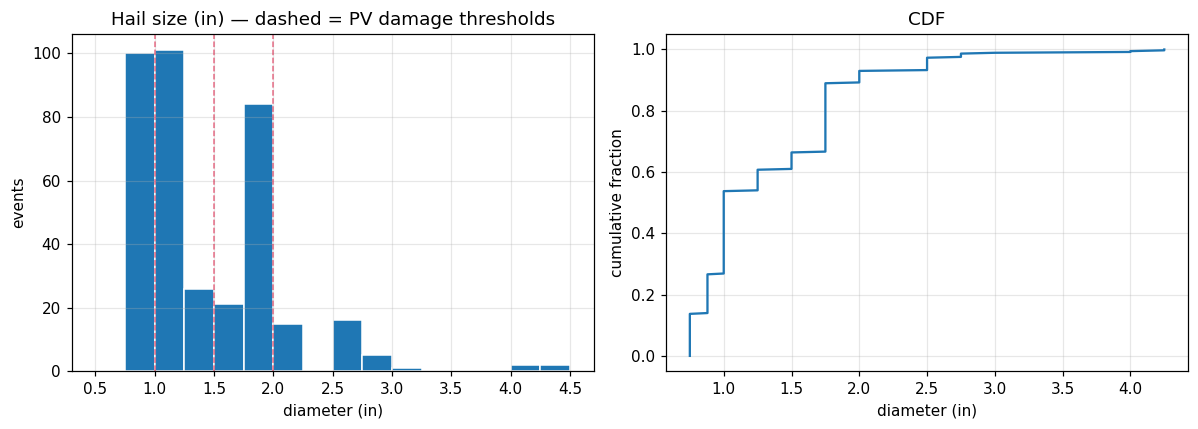

,hail_size_in
count,373.00
mean,1.33
std,0.58
min,0.75
25%,0.88
50%,1.00
75%,1.75
max,4.25


In [12]:
m = ev["magnitude_in"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(m, bins=np.arange(0.5, m.max() + 0.5, 0.25), edgecolor="white")
for thr in (1.0, 1.5, 2.0):
    ax[0].axvline(thr, color="crimson", ls="--", lw=1, alpha=0.6)
ax[0].set(title="Hail size (in) — dashed = PV damage thresholds", xlabel="diameter (in)", ylabel="events")
ax[1].plot(np.sort(m), np.linspace(0, 1, len(m)))
ax[1].set(title="CDF", xlabel="diameter (in)", ylabel="cumulative fraction")
plt.tight_layout(); plt.show()
m.describe().round(2).to_frame("hail_size_in")

## 5 · Temporal coverage

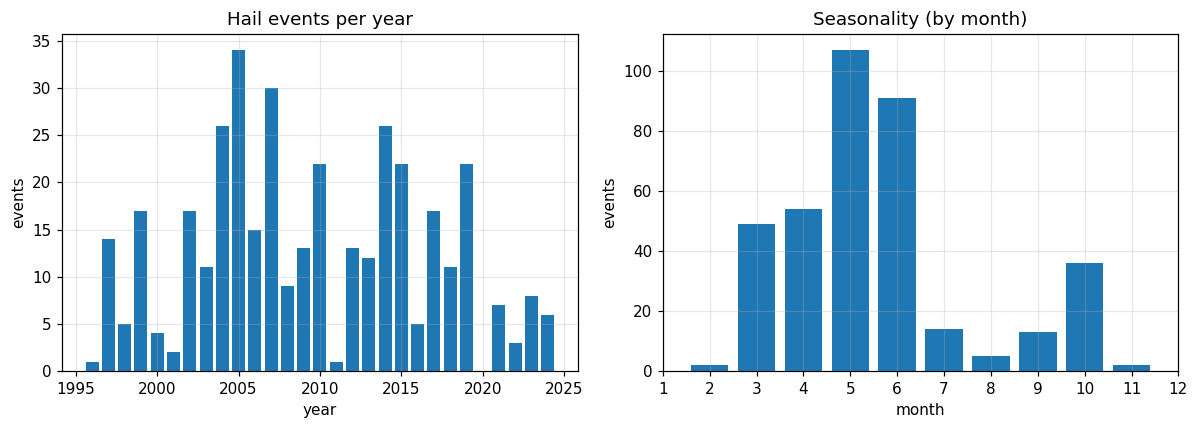

window: 1996–2024 · mean events/yr ≈ 12.9


In [13]:
yrs = ev["year"].dropna().astype(int)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
per_year = yrs.value_counts().sort_index()
ax[0].bar(per_year.index, per_year.values)
ax[0].set(title="Hail events per year", xlabel="year", ylabel="events")
per_month = ev["begin_dt"].dt.month.value_counts().sort_index()
ax[1].bar(per_month.index, per_month.values)
ax[1].set(title="Seasonality (by month)", xlabel="month", ylabel="events", xticks=range(1, 13))
plt.tight_layout(); plt.show()
print(f"window: {yrs.min()}–{yrs.max()} · mean events/yr ≈ {len(ev) / (yrs.max() - yrs.min() + 1):.1f}")

## 6 · Spatial distribution around the site

The **region** is a **50-mi-radius circle** (the NOAA API `distance` query) — drawn below. Every report
falls inside it by construction.

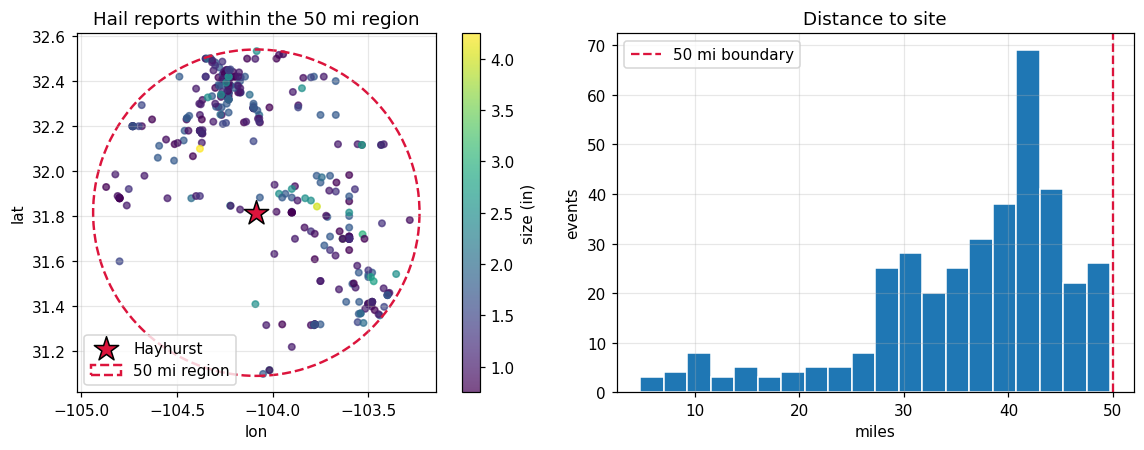

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sc = ax[0].scatter(ev["BEGIN_LON"], ev["BEGIN_LAT"], c=ev["magnitude_in"], cmap="viridis", s=18, alpha=0.7)
ax[0].scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=280, color="crimson",
              edgecolor="black", zorder=5, label="Hayhurst")
# the region: a 50-mi-radius circle (the NOAA `distance` query), drawn as a lat/lon ellipse
dlat = PRIMARY_RADIUS / 69.0
dlon = PRIMARY_RADIUS / (69.0 * np.cos(np.radians(ASSET["lat"])))
ax[0].add_patch(Ellipse((ASSET["lon"], ASSET["lat"]), width=2 * dlon, height=2 * dlat,
                        fill=False, ec="crimson", ls="--", lw=1.6, label=f"{PRIMARY_RADIUS} mi region"))
ax[0].set_aspect(1 / np.cos(np.radians(ASSET["lat"])))   # make the geographic circle look round
ax[0].set(title=f"Hail reports within the {PRIMARY_RADIUS} mi region", xlabel="lon", ylabel="lat"); ax[0].legend()
fig.colorbar(sc, ax=ax[0], label="size (in)")
ax[1].hist(ev["distance_mi"].dropna(), bins=20, edgecolor="white")
ax[1].axvline(PRIMARY_RADIUS, color="crimson", ls="--", lw=1.5, label=f"{PRIMARY_RADIUS} mi boundary")
ax[1].set(title="Distance to site", xlabel="miles", ylabel="events"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7 · Frequency reconciliation — NRI vs NOAA (an M0 caution)

The key M0 insight. NRI county `hail_afreq` and raw NOAA report counts **disagree by an order of
magnitude**, and they *should*: NRI normalizes to the county; NOAA report counts inflate with search
radius and population density. **Neither is the asset's true hit rate `λ_asset`.** Turning report density
into a defensible per-asset frequency is the **Phase-3 coupling** job (Minkowski hit-probability) — not
something to read off raw counts. This is precisely the trap the old `F/A` spatial factor fell into.

> **Why raw counts mislead but `λ_asset` shouldn't (the cancellation):** with `λ_asset = λ_collection × p`
> and `p ≈ footprint / search_area`, growing the radius grows `λ_collection` (≈ raw counts) ∝ `search_area`
> while `p` shrinks ∝ `1/search_area` — the `search_area` **cancels**, so `λ_asset` converges
> (≈ event-density × footprint), independent of the arbitrary radius. That cancellation is the whole reason
> we refuse to read frequency off raw counts here and defer `λ_asset` to the Phase-3 coupling.
> (Refs: the §2 cross-reference — `hazard_math/01`, `discussion/gpt/03`.)

In [15]:
afreq = float(nri_hail.loc["hail_afreq", "value"])
recon = scan_tbl.assign(nri_county_afreq=afreq).rename(columns={"events_per_yr": "noaa_obs_per_yr"})
recon[["radius_mi", "events", "noaa_obs_per_yr", "nri_county_afreq"]]

,radius_mi,events,noaa_obs_per_yr,nri_county_afreq
0,25,40,1.4,0.822325
1,50,373,12.9,0.822325
2,100,1762,60.8,0.822325


## 8 · The candidate M0 "event record" → Phase 2

What an M0 hail event carries forward into the **event catalog** (Phase 2). Saved to a (gitignored)
parquet as the first tangible artifact of the pipeline. (Note: we carry `EPISODE_ID` too — Phase 2 needs
it to decluster reports that belong to the same storm system.)

In [16]:
M0 = (ev.loc[:, ["EVENT_ID", "EPISODE_ID", "begin_dt", "BEGIN_LAT", "BEGIN_LON", "distance_mi", "magnitude_in", "EVENT_TYPE"]]
        .rename(columns={"EVENT_ID": "event_id", "EPISODE_ID": "episode_id", "begin_dt": "datetime",
                         "BEGIN_LAT": "lat", "BEGIN_LON": "lon", "magnitude_in": "intensity_in", "EVENT_TYPE": "peril"}))
out = ROOT / "data" / "hail"
out.mkdir(parents=True, exist_ok=True)
M0.to_parquet(out / "hayhurst_hail_m0_noaa_50mi.parquet", index=False)   # → top-level data/ (gitignored)
print(f"M0 event records: {len(M0)} → {out / 'hayhurst_hail_m0_noaa_50mi.parquet'}")
M0.head()

M0 event records: 373 → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m0_noaa_50mi.parquet


,event_id,episode_id,datetime,lat,lon,distance_mi,intensity_in,peril
0,454280,75164,2013-06-16 16:21:00+00:00,32.1200,-103.5560,37.466969,1.00,Hail
1,454281,75165,2013-06-19 13:39:00+00:00,32.3823,-104.2211,39.927705,0.88,Hail
2,454284,75165,2013-06-19 16:05:00+00:00,32.4145,-103.8399,43.776012,0.88,Hail
3,461017,76438,2013-06-17 13:14:00+00:00,32.2000,-104.7300,46.160213,1.25,Hail
4,461018,76438,2013-06-17 13:20:00+00:00,32.2000,-104.7300,46.160213,1.50,Hail


### Findings & open questions (→ Phase 2/3)

- **Hayhurst hail:** NRI rates it *"Relatively Moderate"* (county `hail_afreq` ≈ 0.82/yr); within 50 mi
  there are a few hundred NOAA hail reports (1996–2024), sizes up to ~4 in.
- **Radius drives counts, not physics** — 25/50/100 mi give wildly different totals. **Open (Phase 3):**
  the footprint/coupling treatment that converts reports → `λ_asset`. Do **not** read frequency off raw counts.
- **Episode vs event** — some reports share an `EPISODE_ID` (one storm). **Open (Phase 2):** decluster so
  one storm isn't counted as many independent events.
- **Severity right tail** (≥ 1–2 in) is what will drive loss — keep the full distribution, never a mean (Phase 4/5).
- **Method-neutral:** everything here is just *reading the evidence*. The correctness fight starts at coupling + loss.